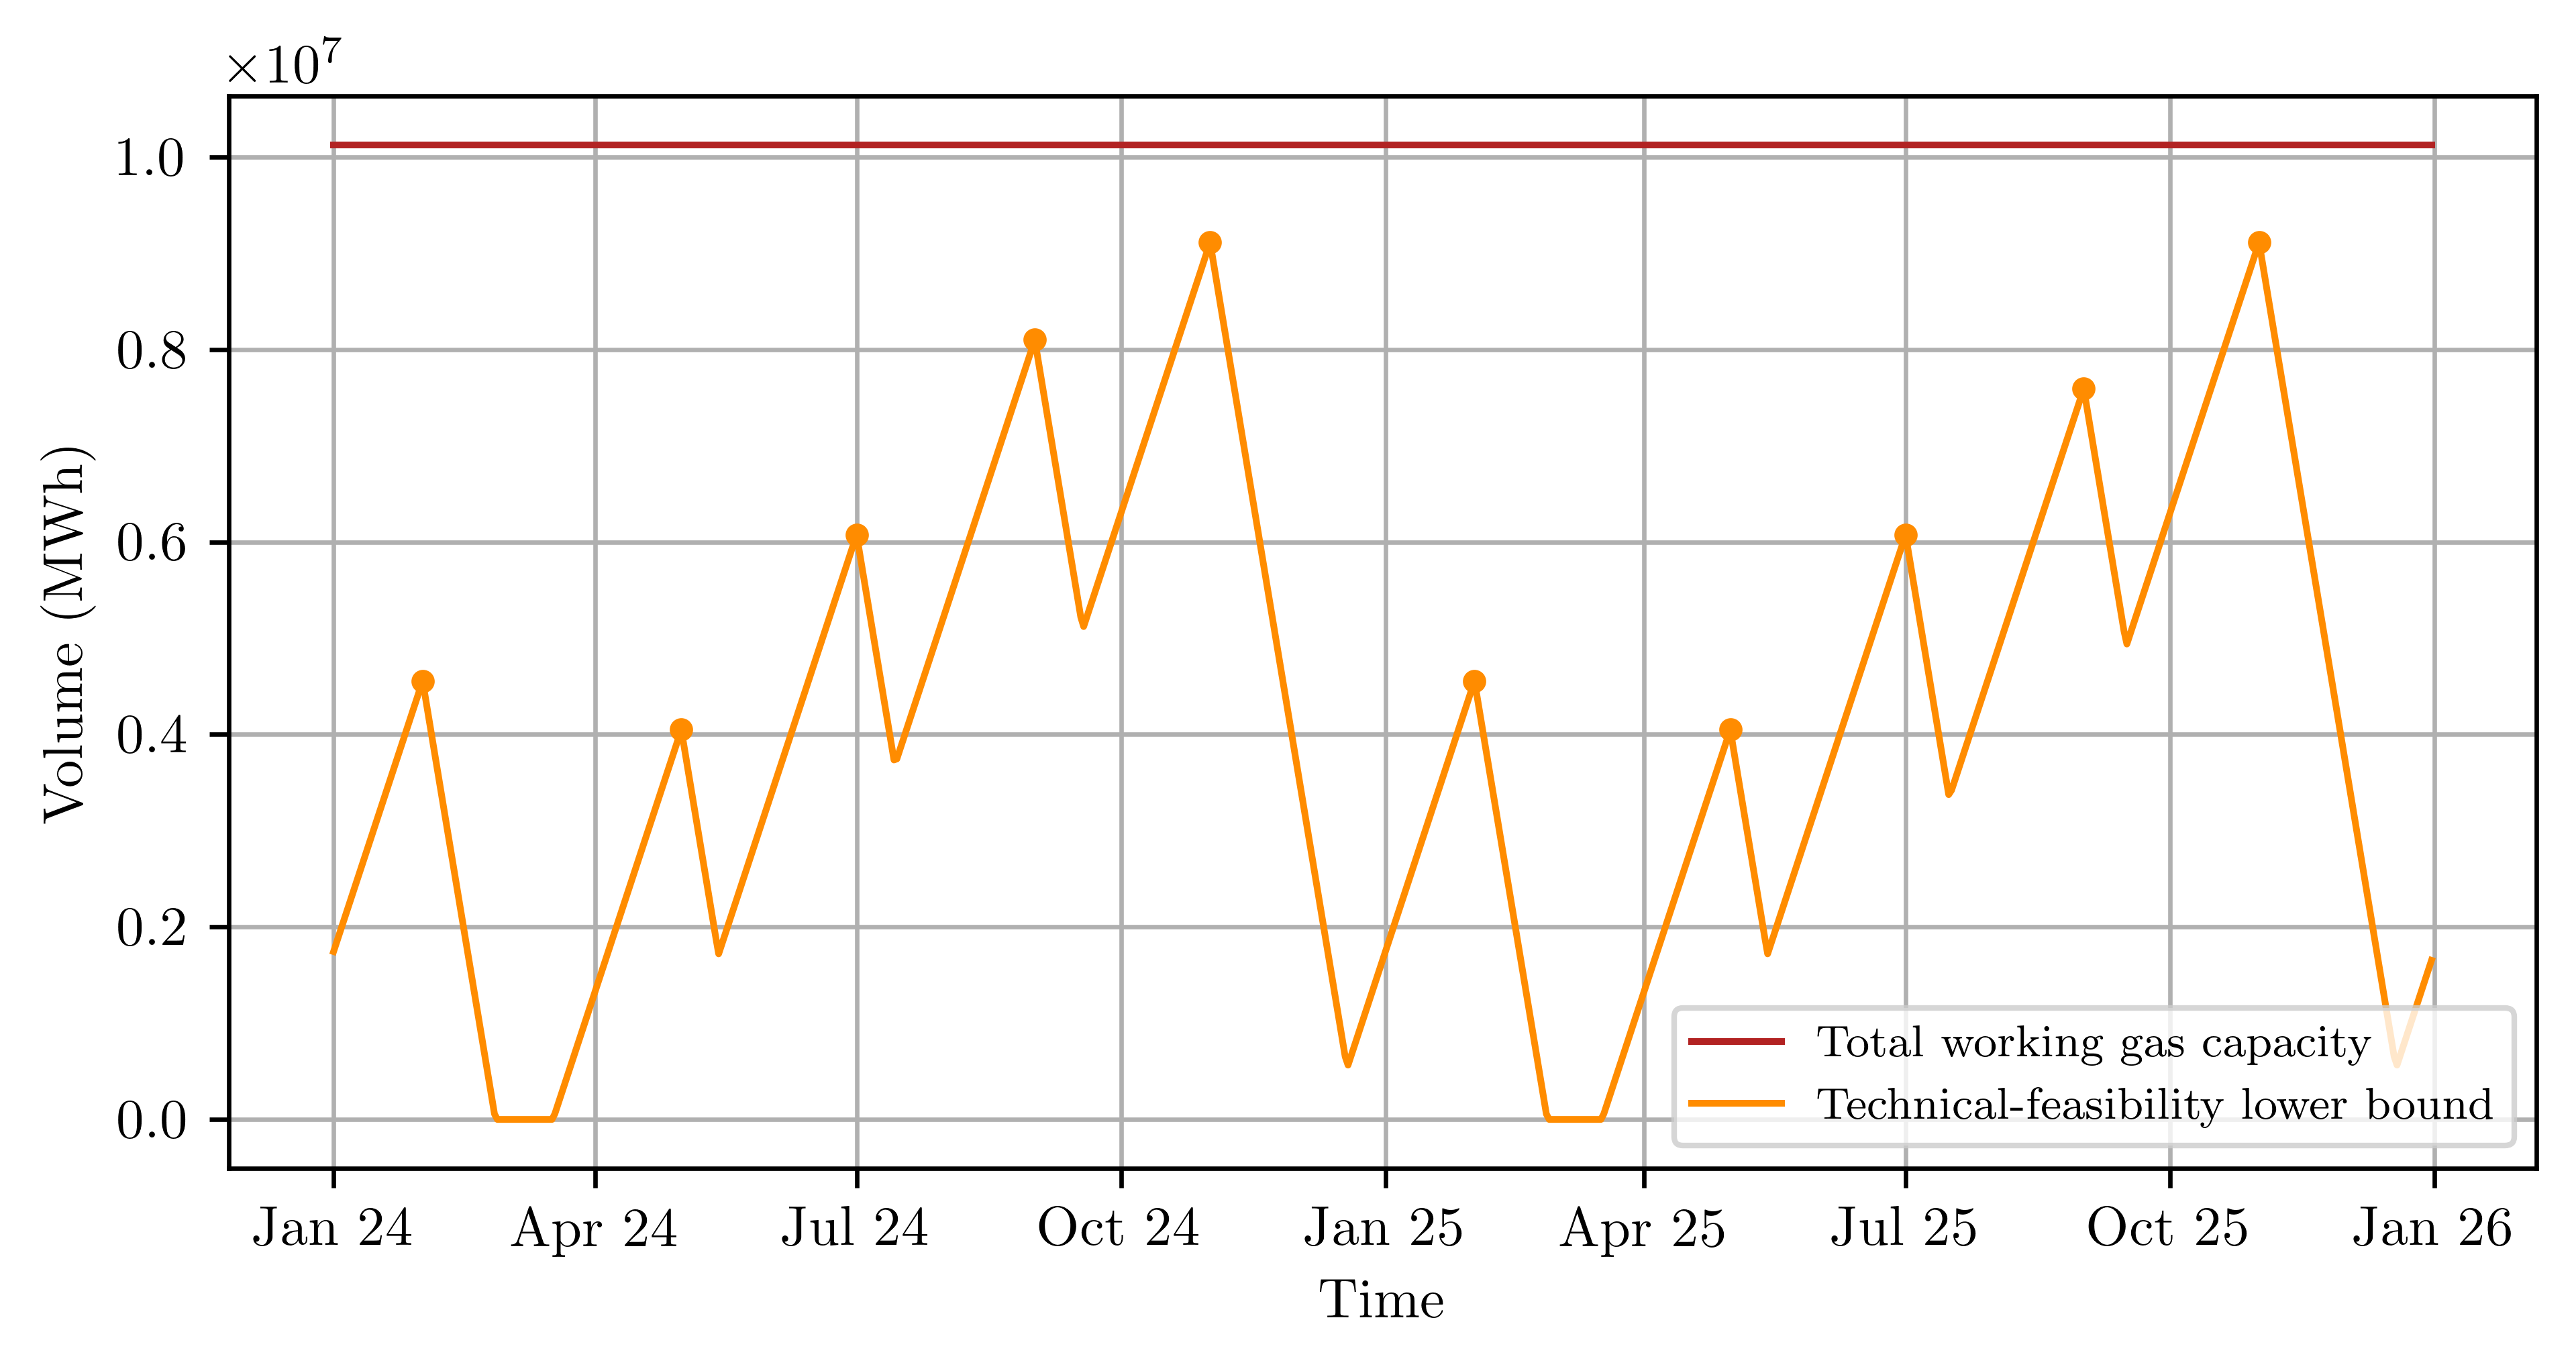

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import numpy as np
import pandas as pd

vmin = 0
vmax = 10125000
inj_max = 90720
wdr_max = 180000

# ---- Restrict period ----
start_date = "2024-01-01"
end_date   = "2025-12-31"

date_range = pd.date_range(start=start_date, end=end_date, freq="D")

# ---- Two-year cycle ----
cycle_start = pd.Timestamp("2024-01-01")
cycle_length = 365 + 366  # 731 days

anchors = pd.to_datetime([
    "2024-02-01",
    "2024-05-01",
    "2024-07-01",
    "2024-09-01",
    "2024-11-01",
    "2025-02-01",
    "2025-05-01",
    "2025-07-01",
    "2025-09-01",
    "2025-11-01",
])

anchor_values = vmax * np.array([
    0.45, 0.40, 0.60, 0.80, 0.90,
    0.45, 0.40, 0.60, 0.75, 0.90
])

# Convert dates to integer day positions in the 2-year cycle
date_x = (date_range - cycle_start).days.values
anchor_x = (anchors - cycle_start).days.values

# ---- Cyclic extension ----
# Include previous/current/next cycles so the floor respects both
# backward-looking withdrawal feasibility and forward-looking injection
# feasibility across the two-year repeating pattern.
anchor_x_ext = np.r_[
    anchor_x - cycle_length,
    anchor_x,
    anchor_x + cycle_length,
]
anchor_y_ext = np.r_[
    anchor_values,
    anchor_values,
    anchor_values,
]

# ---- Technical-feasibility floor ----
# For each date t, compute the minimum inventory needed to satisfy both
# future-anchor injection feasibility and past-anchor withdrawal feasibility.
feasible_floor = np.empty(len(date_x), dtype=np.float64)

for i, t in enumerate(date_x):
    future_mask = anchor_x_ext >= t
    past_mask = anchor_x_ext <= t

    days_to_future_anchors = anchor_x_ext[future_mask] - t
    days_from_past_anchors = t - anchor_x_ext[past_mask]

    required_for_future = (
        anchor_y_ext[future_mask] - inj_max * days_to_future_anchors
    ).max()
    required_from_past = (
        anchor_y_ext[past_mask] - wdr_max * days_from_past_anchors
    ).max()

    # Apply both technical feasibility AND minimum inventory.
    feasible_floor[i] = np.clip(
        max(required_for_future, required_from_past),
        vmin,
        vmax,
    )

# ---- Plot ----
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

ax.plot(
    date_range,
    np.full(len(date_range), vmax),
    color="firebrick",
    lw=1.2,
    label="Total working gas capacity"
)

ax.plot(
    date_range,
    feasible_floor,
    color="darkorange",
    lw=1.2,
    label="Technical-feasibility lower bound"
)

# Optional: show the anchor points
ax.scatter(
    anchors,
    anchor_values,
    s=10,
    color="darkorange",
    zorder=3
)

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.grid(True)

# ---- Ticks ----
tick_dates = pd.date_range(
    start="2024-01-01",
    end=pd.Timestamp("2025-12-31") + pd.DateOffset(months=1),
    freq="3MS"
)

ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

ax.legend(loc="lower right", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/GSD_min_max_inventory_constraints.png")
plt.show()
